In [1]:
import h5py
# import jax
# jax.config.update("jax_enable_x64", True)
# from jax import numpy as jnp
# from jax import jit ,vmap
from scipy.interpolate import griddata
import matplotlib.pyplot as plt
# from scipy.signal import convolve2d, fftconvolve # check jax
# from jax.scipy.signal import fftconvolve
# from jax.scipy.interpolate import RegularGridInterpolator
# from jax.scipy.ndimage import map_coordinates
import time

import os
import numpy
import numpy as np

from numpy.random import randint
import sklearn as sk
from sklearn.mixture import GaussianMixture # jaxxx??? # Hyakkk
from sklearn.decomposition import SparsePCA
from scipy.io import loadmat
import matplotlib as mpl
from matplotlib.colors import ListedColormap
# Seaborn colormap
import seaborn as sns
sns_list = sns.color_palette('deep').as_hex()
sns_list.insert(0, '#ffffff')  # Insert white at zero position
sns_cmap = ListedColormap(sns_list)
# import cv2
cm = sns_cmap
from sklearn.metrics import adjusted_rand_score, adjusted_mutual_info_score, jaccard_score
from sklearn.metrics.cluster import normalized_mutual_info_score

mpl_colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728',
            '#9467bd', '#8c564b', '#e377c2', '#7f7f7f',
            '#bcbd22', '#17becf']


## Load PIV Results post sPCA

note sPCA is necessary here since we want to compare reduced clusters

In [4]:
# simple data load
load_dir = 'PIV/plotting/data/support_x_22_support_y_25/'

nc = 9
nfeatures=5

cluster_idx = np.load(load_dir + 'nc9/cluster_idx.npy')
cluster_idx_im = np.load(load_dir + 'nc9/cluster_idx_im.npy')

# also load grid + features
xx = np.load(load_dir + 'terms/xx.npy')
yy = np.load(load_dir + 'terms/yy.npy')
features = np.load(load_dir + 'terms/features.npy')

y_cutoff = 720

nx = xx.size
ny = yy.size


[120, 60, 300, 15, 15, 40, 90, 15, 60]


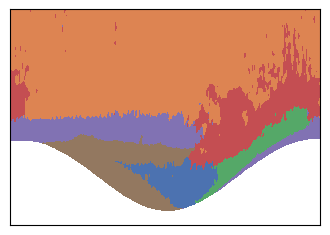

<Figure size 640x480 with 0 Axes>

In [5]:
# sPCA

def test_alpha_sPCA_GMM_model(alphas, features,cluster_idx,cluster_idx_to_test,nfeatures=6):
    err = np.zeros([len(alphas)])  # Error defined as norm of inactive terms
    sparsity = np.zeros([len(alphas)])
    for k in range(len(alphas)):
        i = cluster_idx_to_test
        # Identify points in the field corresponding to each cluster
        feature_idx = np.nonzero(cluster_idx==i)[0]
        cluster_features = features[feature_idx, :]
        spca = SparsePCA(n_components=1, alpha=alphas[k])
        spca.fit(cluster_features)
        active_terms = np.nonzero(spca.components_[0])[0]
        inactive_terms = [feat for feat in range(nfeatures) if feat not in active_terms ]

        err[k] += np.linalg.norm(cluster_features[:, inactive_terms])

    return err

cluster_err = []
alphas = [0.1,0.175,0.25,0.375,0.5,0.625,0.75,0.875,1,5,6,7,10,15,20,25,27.5,30,40,50,60,70,80,90,100,120,140,145,150,160,200,250,300,350,400]

for i in range(nc):
    cluster_err.append(test_alpha_sPCA_GMM_model(alphas, features, cluster_idx-1, i, nfeatures=5))


def train_sPCA_model_multi_alpha(opt_alpha_list, features, nfeatures, nc, cluster_idx):
    spca_model = np.zeros([nc, nfeatures])
    for i in range(nc):
        alpha_opt = opt_alpha_list[i]
        feature_idx = np.nonzero(cluster_idx==i)[0]
        cluster_features = features[feature_idx, :]
        spca = SparsePCA(n_components=1, alpha=alpha_opt)
        spca.fit(cluster_features)
        # print('GMM Cluster {0}:'.format(i))
        active_terms = np.nonzero(spca.components_[0])[0]
        if len(active_terms)>0:
            # print([labels[k] for k in active_terms])
            spca_model[i, active_terms] = 1  # Set to 1 for active terms in model
        else: print('None')

    return spca_model

err_threshold = 225#145

alpha_opt = []
for i in range(nc):
    for j,err in enumerate(cluster_err[i]):
        if err > err_threshold:
            alpha_opt.append(alphas[j-1]) # append the last alpha value that was not above the error threshold
            break
        elif j == cluster_err[i].size-1:
            alpha_opt.append(alphas[j-1]) # append the higest alpha value tested
            print(f'err higher than max threshold for cluster {i+1}')
            break

print(alpha_opt)

optimal_alphas = alpha_opt

spca_model = train_sPCA_model_multi_alpha(optimal_alphas, features, nfeatures, nc, cluster_idx.flatten()-1)

balance_models, model_index = np.unique(spca_model, axis=0, return_inverse=True)

# print(balance_models)
nmodels = balance_models.shape[0]

balance_idx = np.array([model_index[i] for i in cluster_idx.flatten() - 1])


cluster_idx_to_fill = cluster_idx_im.copy().flatten()
indices = np.where(~np.isnan(cluster_idx_to_fill))
cluster_idx_to_fill[indices] = balance_idx
cluster_idx_to_fill = np.reshape(cluster_idx_to_fill, (ny,nx))[:y_cutoff-5,:]

# Save balance_model and balance maps & plot them too
plt.figure(figsize = (4,2.8))
plt.pcolormesh(xx[22:-22],yy[:y_cutoff-5], cluster_idx_to_fill[:,22:-22]+1, cmap = cm, vmin=-0.5, vmax=cm.N-0.5)
# plt.colorbar(boundaries=np.arange(0.5, int(nmodels)+1.5), ticks=np.arange(1, int(nmodels)+2))
# plt.margins(10)
plt.xticks([])
plt.yticks([])
plt.ylim(0,np.max(yy[:y_cutoff-5]))
# plt.savefig(f'sPCA_ClusterDomain_WW_PIV.png',bbox_inches='tight',transparent=True)
plt.show()
plt.clf()

In [4]:
# Make sure to save final clustering to an array specifically designated as PIV
balance_models_PIV = balance_models
model_index_PIV = model_index

indices_PIV = indices

balance_idx_PIV = balance_idx

cluster_idx_to_fill_used_PIV = cluster_idx_to_fill[:,22:-22]+1
xx_used_PIV = xx[22:-22]
yy_used_PIV = yy[:y_cutoff-5]

## Load DNS Results

In [7]:
# simple data load
load_dir = 'DNS/plotting/data/support_x_20_support_y_15_grid_spacing_0.001_TFDegree_5/'

nc = 11
trial = 0

cluster_idx = np.load(load_dir + f'nc{nc}/trial_{trial}/cluster_idx.npy')
masked_x_coords_DNS_grid = np.load(load_dir + f'nc{nc}/trial_{trial}/masked_x_coords_DNS_grid.npy')
masked_y_coords_DNS_grid = np.load(load_dir + f'nc{nc}/trial_{trial}/masked_y_coords_DNS_grid.npy')

nfeatures=6

# also load features
features = np.load(load_dir + 'terms/features.npy')

[6, 25, 30, 15, 12, 20, 0.625, 25, 2, 1, 6]


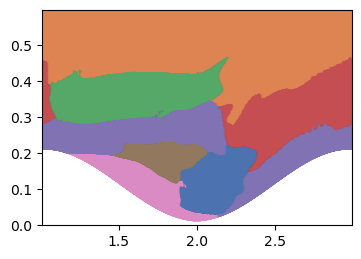

<Figure size 640x480 with 0 Axes>

In [6]:
#sPCA

cluster_err = []
alphas = [0.05,0.0625,0.075,0.0875,0.1,0.175,0.25,0.375,0.5,0.625,0.75,0.875,1,2,3,4,5,6,7,8,9,10,11,12,14,15,16,18,20,25,27.5,30,40,50,60,70,80,90,100,150,200,250,300,350,400,500]

for i in range(nc):
    cluster_err.append(test_alpha_sPCA_GMM_model(alphas, features, cluster_idx-1, i, nfeatures=6))

err_threshold = 45

alpha_opt = []
for i in range(nc):
    for j,err in enumerate(cluster_err[i]):
        if err > err_threshold:
            alpha_opt.append(alphas[j-1]) # append the last alpha value that was not above the error threshold
            break

print(alpha_opt)

optimal_alphas = alpha_opt

spca_model = train_sPCA_model_multi_alpha(optimal_alphas, features, nfeatures, nc, cluster_idx.flatten()-1)

balance_models, model_index = np.unique(spca_model, axis=0, return_inverse=True)

# print(balance_models)
nmodels = balance_models.shape[0]

balance_idx = np.array([model_index[i] for i in cluster_idx.flatten() - 1])

indices = []
for i in range(masked_y_coords_DNS_grid.size):
    if masked_y_coords_DNS_grid[i] < 0.6:
        indices.append(i)

# Save balance_model and balance maps & plot them too
plt.figure(figsize = (4,2.8))
plt.scatter(masked_x_coords_DNS_grid[indices],masked_y_coords_DNS_grid[indices], 2, balance_idx[indices]+1, cmap = cm, vmin=-0.5, vmax=cm.N-0.5)
# plt.colorbar(boundaries=np.arange(0.5, int(nmodels)+1.5), ticks=np.arange(1, int(nmodels)+2))
# plt.xticks([])
# plt.yticks([])
plt.xlim(np.min(masked_x_coords_DNS_grid[indices]),np.max(masked_x_coords_DNS_grid[indices]))
plt.ylim(0,np.max(masked_y_coords_DNS_grid[indices]))
# plt.savefig(save_dir + f'trial{i}/sPCA_ClusterDomain,nc{nc}')
# plt.savefig(f'sPCA_ClusterDomain_WW_DNS.png',dpi=480,bbox_inches='tight',transparent=True)
plt.show()
plt.clf()

In [7]:
balance_models_DNS = balance_models
model_index_DNS = model_index

balance_idx_DNS = balance_idx

indices_DNS = indices

balance_idx_to_fill_used_DNS = balance_idx[indices]+1#note, DNS is unstructered, whereas PIV is a native evenly(-ish) spaced grid
xx_used_DNS = masked_x_coords_DNS_grid[indices]
yy_used_DNS = masked_y_coords_DNS_grid[indices]

### Convert PIV image coords to physical coords

In [9]:
scale = 0.2/239

PIV_x_physical = (xx-102)*scale +1.0
PIV_y_physical = (yy-21)*scale

In [11]:
#truncate x according to max/min DNS since PIX x-domain is larger than DNS:
PIV_x_left_trunc = np.argmin(np.abs(PIV_x_physical-np.min(xx_used_DNS)))
PIV_x_right_trunc = np.argmin(np.abs(PIV_x_physical-np.max(xx_used_DNS)))

PIV_x_physical_used = PIV_x_physical[PIV_x_left_trunc:PIV_x_right_trunc]
#truncate y according GMM cutoff since PIV y-domain is smaller than DNS:
PIV_y_physical_used = PIV_y_physical[:y_cutoff-5]

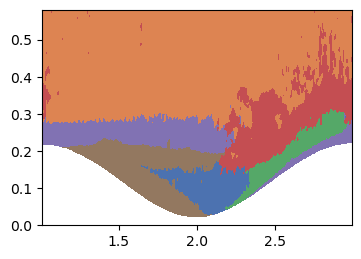

<Figure size 640x480 with 0 Axes>

In [12]:
# Save balance_model and balance maps & plot them too
plt.figure(figsize = (4,2.8))
plt.pcolormesh(PIV_x_physical_used,PIV_y_physical_used, cluster_idx_to_fill[:,PIV_x_left_trunc:PIV_x_right_trunc]+1, cmap = cm, vmin=-0.5, vmax=cm.N-0.5)
# plt.colorbar(boundaries=np.arange(0.5, int(nmodels)+1.5), ticks=np.arange(1, int(nmodels)+2))
# plt.margins(10)
# plt.xticks([])
# plt.yticks([])
plt.ylim(0,np.max(PIV_y_physical_used))
# plt.savefig(f'sPCA_ClusterDomain_WW_PIV.png',bbox_inches='tight',transparent=True)
plt.show()
plt.clf()

## Visualize grids look close to matching (no need to be perfect since we're doing "nearest" to interpolate later)

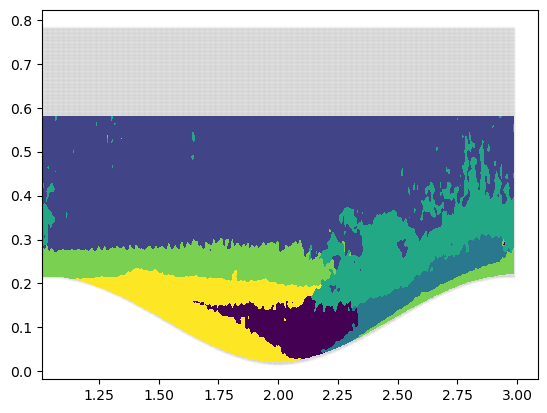

In [13]:
plt.scatter(masked_x_coords_DNS_grid, masked_y_coords_DNS_grid, s= 0.00001)
plt.pcolormesh(PIV_x_physical_used, PIV_y_physical_used, cluster_idx_to_fill[:,PIV_x_left_trunc:PIV_x_right_trunc]+1)

Setup interp grid

In [14]:
X_PIV_mesh, Y_PIV_mesh = np.meshgrid(PIV_x_physical_used, PIV_y_physical_used)

mask = ~np.isnan(cluster_idx_to_fill[:,PIV_x_left_trunc:PIV_x_right_trunc])

X_interp = X_PIV_mesh[mask]
Y_interp = Y_PIV_mesh[mask]

In [17]:
# Interp DNS clusters onto PIV
interp_DNS_labels = griddata(
                        np.array([xx_used_DNS, yy_used_DNS]).T,
                        balance_idx_to_fill_used_DNS-1,
                        np.array([X_interp, Y_interp]).T,
                        method='nearest'
                    )

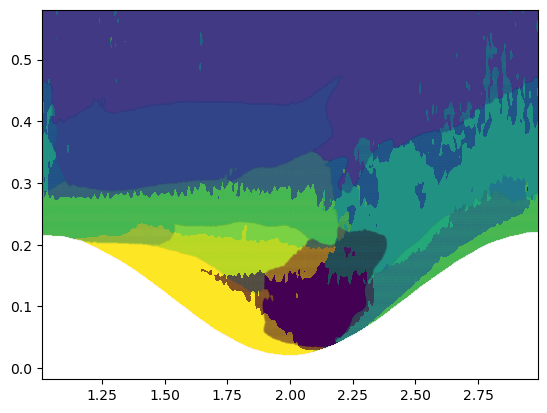

In [20]:
plt.pcolormesh(PIV_x_physical_used, PIV_y_physical_used, cluster_idx_to_fill[:,PIV_x_left_trunc:PIV_x_right_trunc]+1)
plt.scatter(X_PIV_mesh[mask], Y_PIV_mesh[mask],s=0.0001,c=interp_DNS_labels)

# Ensure Alignment between DNS and PIV DB cluster arrays

In [22]:
ari = adjusted_rand_score((cluster_idx_to_fill[:,PIV_x_left_trunc:PIV_x_right_trunc])[mask], interp_DNS_labels)
nmi = normalized_mutual_info_score((cluster_idx_to_fill[:,PIV_x_left_trunc:PIV_x_right_trunc])[mask], interp_DNS_labels)
ami = adjusted_mutual_info_score((cluster_idx_to_fill[:,PIV_x_left_trunc:PIV_x_right_trunc])[mask], interp_DNS_labels)

In [23]:
print(ari)
print(nmi)
print(ami)

0.4497050092190311
0.5375338772343057
0.5375303619391104


# Double check overlap is correct

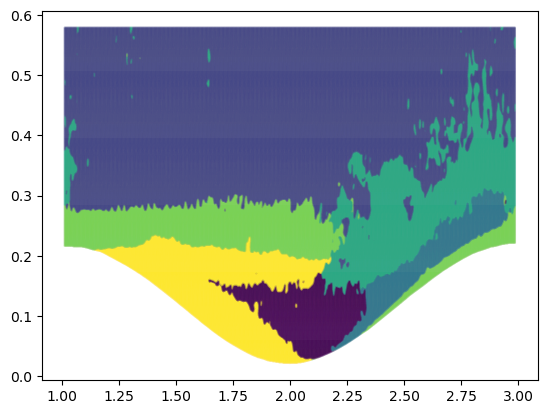

In [24]:
plt.scatter(X_PIV_mesh[mask], Y_PIV_mesh[mask],s=0.001, c=(cluster_idx_to_fill[:,PIV_x_left_trunc:PIV_x_right_trunc])[mask]+1)

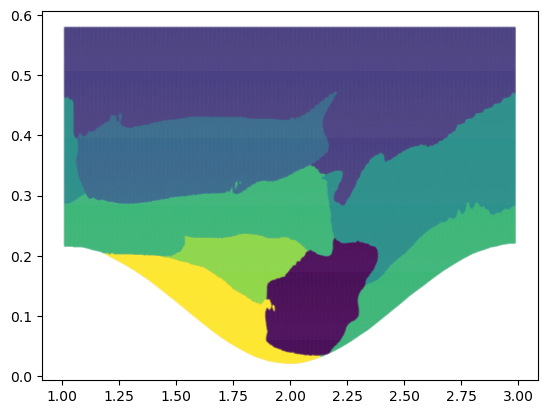

In [26]:
plt.scatter(X_PIV_mesh[mask], Y_PIV_mesh[mask],s=0.001, c=interp_DNS_labels)

# Hugarian matching + Jaccard index

In [27]:
from scipy.optimize import linear_sum_assignment
from sklearn.metrics import confusion_matrix

def hungarian_match_labels(y_true, y_pred):
    """
    Match cluster labels in y_pred to y_true using Hungarian assignment.

    Parameters
    ----------
    y_true : array-like
        Reference cluster labels.
    y_pred : array-like
        Cluster labels to permute.

    Returns
    -------
    y_pred_matched : ndarray
        Relabeled y_pred aligned to y_true.
    mapping : dict
        Mapping from original y_pred labels -> matched labels.
    """
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)

    # Get all unique labels
    true_labels = np.unique(y_true)
    pred_labels = np.unique(y_pred)

    # Build overlap/confusion matrix
    cm = confusion_matrix(y_true, y_pred,
                          labels=true_labels)

    # Hungarian assignment (maximize overlap)
    row_ind, col_ind = linear_sum_assignment(-cm)

    # Build label mapping
    mapping = {
        pred_labels[c]: true_labels[r]
        for r, c in zip(row_ind, col_ind)
    }

    # Apply mapping
    y_pred_matched = np.array(
        [mapping.get(label, label) for label in y_pred]
    )

    return y_pred_matched, mapping
    

In [38]:
matched_DNS_labels, mapping = hungarian_match_labels(
    (cluster_idx_to_fill[:,PIV_x_left_trunc:PIV_x_right_trunc])[mask], 
    interp_DNS_labels
)

print(mapping)
# {2: 0, 0: 1, 1: 2}

print(matched_DNS_labels)
# [0 0 0 1 1 1 2 2 2]

{0.0: 0.0, 1.0: 1.0, 2.0: 2.0, 3.0: 3.0, 4.0: 4.0, 5.0: 5.0}
[6. 6. 6. ... 1. 1. 1.]


already matched!

In [40]:
print(jaccard_score((cluster_idx_to_fill[:,PIV_x_left_trunc:PIV_x_right_trunc])[mask], 
               interp_DNS_labels,
               average='micro'))
print(jaccard_score((cluster_idx_to_fill[:,PIV_x_left_trunc:PIV_x_right_trunc])[mask], 
               interp_DNS_labels,
               average='macro'))
print(jaccard_score((cluster_idx_to_fill[:,PIV_x_left_trunc:PIV_x_right_trunc])[mask], 
               interp_DNS_labels,
               average='weighted'))

0.4451407312110155
0.34174203565151073
0.5239876157260362
